In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

# Set style for visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

# Predicting house prices: a regression example


## The Boston Housing Price dataset


We will be attempting to predict the median price of homes in a given Boston suburb in the mid-1970s, given a few data points about the
suburb at the time, such as the crime rate, the local property tax rate, etc.

The dataset we will be using has another interesting difference from our two previous examples: it has very few data points, only 506 in
total, split between 404 training samples and 102 test samples, and each "feature" in the input data (e.g. the crime rate is a feature) has
a different scale. For instance some values are proportions, which take a values between 0 and 1, others take values between 1 and 12,
others between 0 and 100...

Let's take a look at the data:

In [2]:
# Load Boston Housing dataset (fallback for TF 2.16+ where it was deprecated)
try:
    from tensorflow.keras.datasets import boston_housing
    (train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()
except Exception:
    from sklearn.datasets import fetch_openml
    data = fetch_openml(name='boston', version=1, as_frame=False, parser='auto')
    from sklearn.model_selection import train_test_split
    X, y = data.data, data.target.astype(np.float32)
    train_data, test_data, train_targets, test_targets = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
train_data.shape

(404, 13)

In [4]:
test_data.shape

(102, 13)


As you can see, we have 404 training samples and 102 test samples. The data comprises 13 features. The 13 features in the input data are as
follow:

1. Per capita crime rate.
2. Proportion of residential land zoned for lots over 25,000 square feet.
3. Proportion of non-retail business acres per town.
4. Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
5. Nitric oxides concentration (parts per 10 million).
6. Average number of rooms per dwelling.
7. Proportion of owner-occupied units built prior to 1940.
8. Weighted distances to five Boston employment centres.
9. Index of accessibility to radial highways.
10. Full-value property-tax rate per $10,000.
11. Pupil-teacher ratio by town.
12. 1000 * (Bk - 0.63) ** 2 where Bk is the proportion of Black people by town.
13. % lower status of the population.

The targets are the median values of owner-occupied homes, in thousands of dollars:

In [5]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

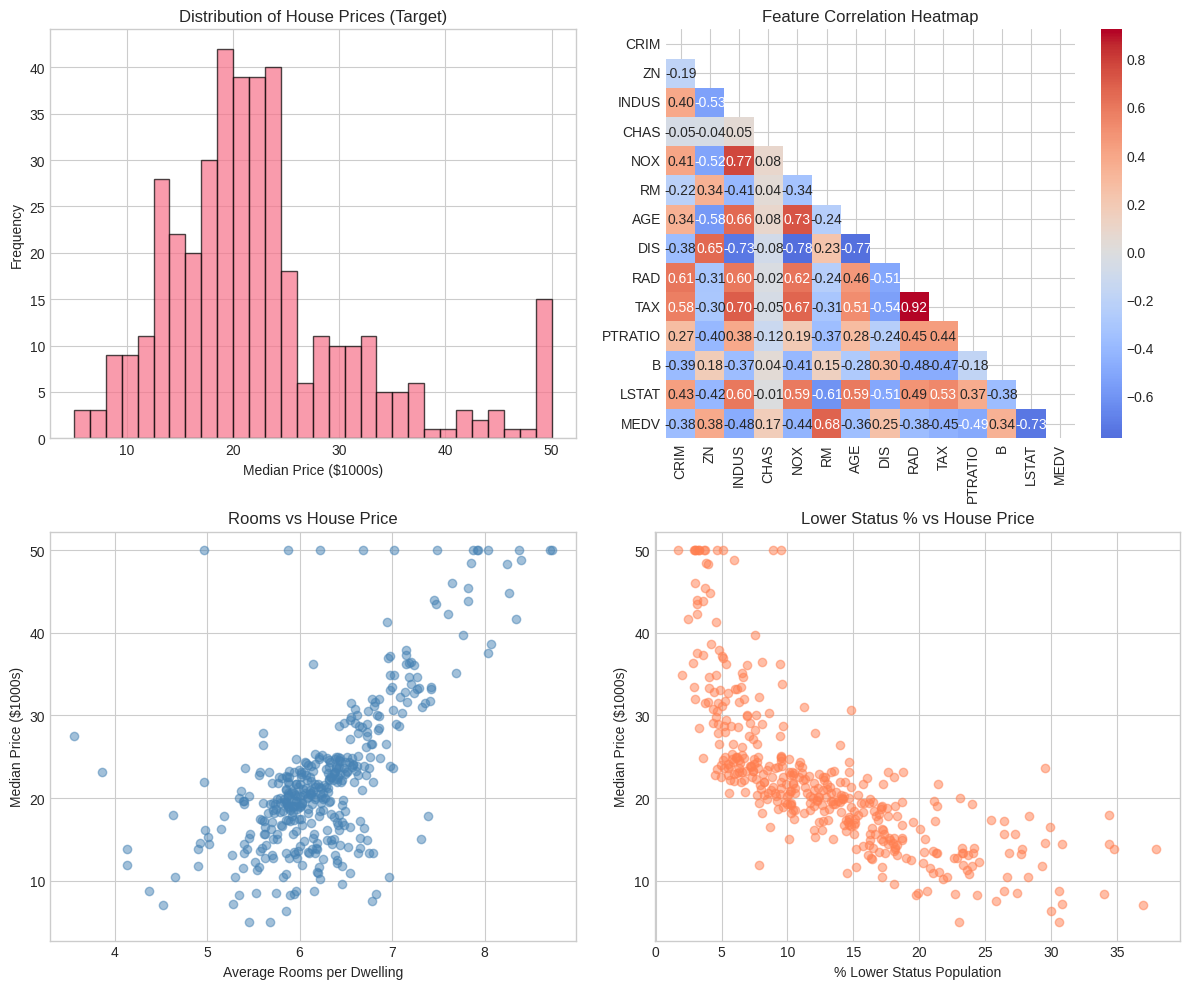

In [6]:
# Data exploration: Create DataFrame for visualization
feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
df = pd.DataFrame(train_data, columns=feature_names)
df['MEDV'] = train_targets

# 1. Distribution of target (house prices)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(train_targets, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median Price ($1000s)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of House Prices (Target)')

# 2. Correlation heatmap
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0, 1], square=True)
axes[0, 1].set_title('Feature Correlation Heatmap')

# 3. Top features vs target (rooms and lower status - typically most correlated)
axes[1, 0].scatter(df['RM'], df['MEDV'], alpha=0.5, c='steelblue')
axes[1, 0].set_xlabel('Average Rooms per Dwelling')
axes[1, 0].set_ylabel('Median Price ($1000s)')
axes[1, 0].set_title('Rooms vs House Price')

axes[1, 1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5, c='coral')
axes[1, 1].set_xlabel('% Lower Status Population')
axes[1, 1].set_ylabel('Median Price ($1000s)')
axes[1, 1].set_title('Lower Status % vs House Price')

plt.tight_layout()
plt.show()


The prices are typically between \$10,000  and  \$50,000. If that sounds cheap, remember this was the mid-1970s, and these prices are not
inflation-adjusted.

## Preparing the data, Normalization


It would be problematic to feed into a neural network values that all take wildly different ranges. The network might be able to
automatically adapt to such heterogeneous data, but it would definitely make learning more difficult. A widespread best practice to deal
with such data is to do feature-wise normalization: for each feature in the input data (a column in the input data matrix), we
will subtract the mean of the feature and divide by the standard deviation, so that the feature will be centered around 0 and will have a
unit standard deviation. This is easily done in Numpy:

In [7]:
# Normalize: use training statistics for both train and test (avoid data leakage)
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)
std[std == 0] = 1  # Avoid division by zero
train_data = (train_data - mean) / std
test_data = (test_data - mean) / std

In [8]:
print("mean: ", mean)
print("std: ", std)

mean:  [3.74511057e+00 1.14801980e+01 1.11044307e+01 6.18811881e-02
 5.57355941e-01 6.26708168e+00 6.90106436e+01 3.74027079e+00
 9.44059406e+00 4.05898515e+02 1.84759901e+01 3.54783168e+02
 1.27408168e+01]
std:  [9.22929073e+00 2.37382770e+01 6.80287253e+00 2.40939633e-01
 1.17147847e-01 7.08908627e-01 2.79060634e+01 2.02770050e+00
 8.68758849e+00 1.66168506e+02 2.19765689e+00 9.39946015e+01
 7.24556085e+00]


## Building our network


Because so few samples are available, we will be using a very small network with two
hidden layers, each with 64 units. In general, the less training data you have, the worse overfitting will be, and using
a small network is one way to mitigate overfitting.

In [9]:
from tensorflow.keras import models
from tensorflow.keras import layers

def build_model():
    # Because we will need to instantiate
    # the same model multiple times,
    # we use a function to construct it.
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu',
                           input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model


Our network ends with a single unit, and no activation (i.e. it will be linear layer).
This is a typical setup for scalar regression (i.e. regression where we are trying to predict a single continuous value).

Note that we are compiling the network with the `mse` loss function -- Mean Squared Error, the square of the difference between the
predictions and the targets, a widely used loss function for regression problems.

We are also monitoring a new metric during training: `mae`. This stands for Mean Absolute Error. It is simply the absolute value of the
difference between the predictions and the targets. For instance, a MAE of 0.5 on this problem would mean that our predictions are off by
\$500 on average.

## K-Fold Cross-Validation and Training

Because we have so few samples, we use K-fold cross-validation to get a more reliable estimate of model performance. Each fold trains on a different split of the data.

In [10]:
from tensorflow.keras import models, layers

def build_model(input_dim):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# K-fold cross-validation
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80
all_mae_histories = []
all_loss_histories = []

for i in range(k):
    print(f'Processing fold {i + 1}/{k}')
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([
        train_data[:i * num_val_samples],
        train_data[(i + 1) * num_val_samples:]
    ], axis=0)
    partial_train_targets = np.concatenate([
        train_targets[:i * num_val_samples],
        train_targets[(i + 1) * num_val_samples:]
    ], axis=0)

    model = build_model(train_data.shape[1])
    history = model.fit(partial_train_data, partial_train_targets,
                       validation_data=(val_data, val_targets),
                       epochs=num_epochs, batch_size=16, verbose=0)
    all_mae_histories.append(history.history['val_mae'])
    all_loss_histories.append(history.history['val_loss'])

Processing fold 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Processing fold 2/4
Processing fold 3/4
Processing fold 4/4


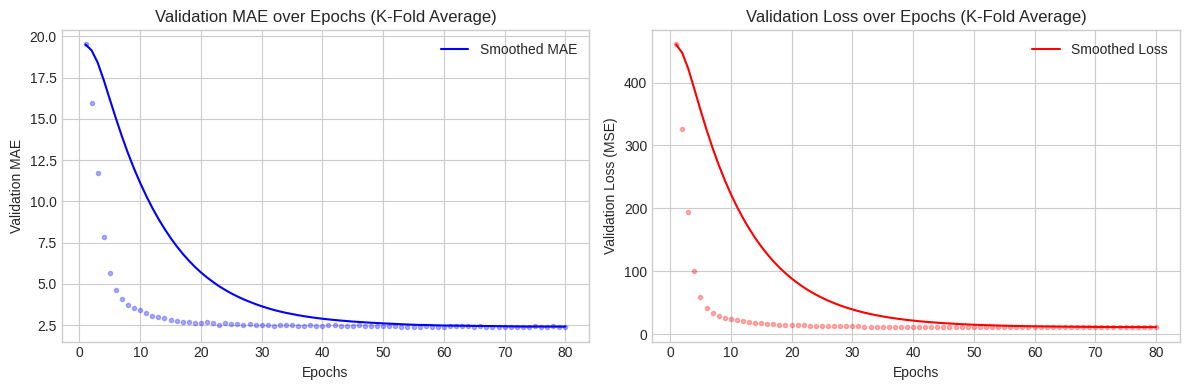

In [11]:
# Average validation MAE across all folds
average_mae_history = np.mean(all_mae_histories, axis=0)
average_loss_history = np.mean(all_loss_histories, axis=0)

# Smooth the curves (exponential moving average)
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

smooth_mae = smooth_curve(average_mae_history)
smooth_loss = smooth_curve(average_loss_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, len(smooth_mae) + 1), smooth_mae, 'b-', label='Smoothed MAE')
axes[0].plot(range(1, len(average_mae_history) + 1), average_mae_history, 'b.', alpha=0.3)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation MAE')
axes[0].set_title('Validation MAE over Epochs (K-Fold Average)')
axes[0].legend()

axes[1].plot(range(1, len(smooth_loss) + 1), smooth_loss, 'r-', label='Smoothed Loss')
axes[1].plot(range(1, len(average_loss_history) + 1), average_loss_history, 'r.', alpha=0.3)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Validation Loss (MSE)')
axes[1].set_title('Validation Loss over Epochs (K-Fold Average)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Final Model Training and Evaluation

Train the final model on the full training set and evaluate on the test set.

In [12]:
# Train final model on full training data
final_model = build_model(train_data.shape[1])
history_final = final_model.fit(train_data, train_targets, epochs=num_epochs, batch_size=16, verbose=0)

# Evaluate on test set
test_mse, test_mae = final_model.evaluate(test_data, test_targets)
print(f'Test MSE: {test_mse:.4f}')
print(f'Test MAE: {test_mae:.4f} (≈ ${test_mae*1000:.0f} average error)')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 18.4482 - mae: 2.7206 
Test MSE: 18.4482
Test MAE: 2.7206 (≈ $2721 average error)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


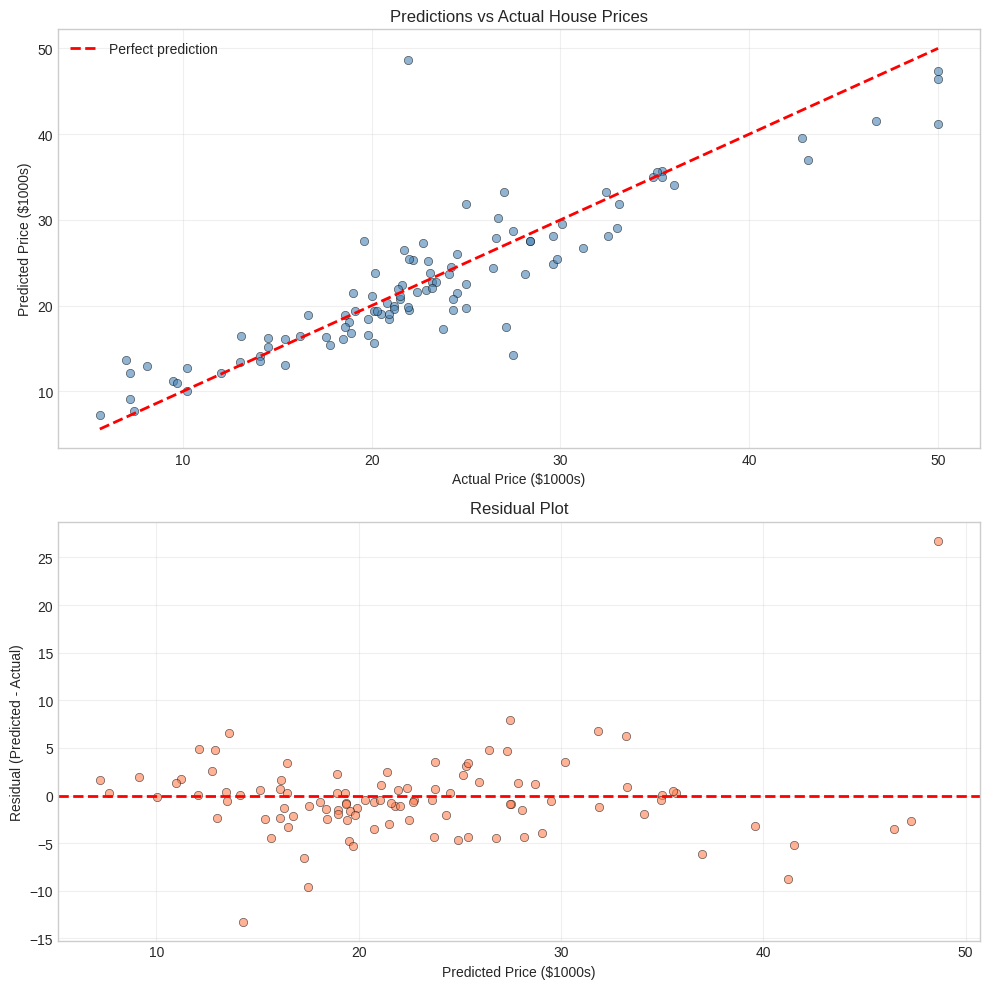

In [13]:
# Predictions vs Actual - Visualization
predictions = final_model.predict(test_data).flatten()

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# 1. Predictions vs Actual scatter plot
axes[0].scatter(test_targets, predictions, alpha=0.6, c='steelblue', edgecolors='black', linewidth=0.5)
max_val = max(test_targets.max(), predictions.max())
min_val = min(test_targets.min(), predictions.min())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($1000s)')
axes[0].set_ylabel('Predicted Price ($1000s)')
axes[0].set_title('Predictions vs Actual House Prices')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual plot
residuals = predictions - test_targets
axes[1].scatter(predictions, residuals, alpha=0.6, c='coral', edgecolors='black', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Price ($1000s)')
axes[1].set_ylabel('Residual (Predicted - Actual)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Problema 4: Regresión de precios con K-Fold avanzado

Usa `DL_Tarea2_Predicting_house_prices.ipynb` como base.
•	Extiende K-fold para comparar al menos 3 arquitecturas distintas (ej. 64-64, 128-64, 64-32-16).
•	Compara al menos 2 funciones de perdida para entrenamiento (MSE vs Huber, por ejemplo).
•	Integra Dropout en las capas ocultas y analiza si mejora o perjudica MAE.
•	Incluye analisis de estabilidad entre folds (media y desviacion estandar de MAE por arquitectura).
Entregable: tabla comparativa por arquitectura/perdida + curva MAE promedio por epoca.


In [14]:
import random, os, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import models, layers, optimizers

# Fijar semillas para reproducibilidad
def fijar_semilla(s=42):
    random.seed(s); np.random.seed(s)
    tf.random.set_seed(s)
    os.environ['PYTHONHASHSEED'] = str(s)

fijar_semilla()

def build_model_arq(units_list, loss_fn='mse', dropout=False, input_dim=13):
    m = models.Sequential()
    for i, u in enumerate(units_list):
        if i == 0:
            m.add(layers.Dense(u, activation='relu', input_shape=(input_dim,)))
        else:
            m.add(layers.Dense(u, activation='relu'))
        if dropout:
            m.add(layers.Dropout(0.3))
    m.add(layers.Dense(1))
    m.compile(optimizer='rmsprop', loss=loss_fn, metrics=['mae'])
    return m

k = 4
num_val = len(train_data) // k
num_epochs = 80

arquitecturas = [
    {'nombre': '64-64',        'units': [64, 64],      'loss': 'mse',                          'dropout': False},
    {'nombre': '128-64',       'units': [128, 64],     'loss': 'mse',                          'dropout': False},
    {'nombre': '64-32-16',     'units': [64, 32, 16],  'loss': 'mse',                          'dropout': False},
    {'nombre': '64-64 Huber',  'units': [64, 64],      'loss': tf.keras.losses.Huber(),        'dropout': False},
    {'nombre': '64-64 Dropout','units': [64, 64],      'loss': 'mse',                          'dropout': True},
]

resultados_p4 = []

for arq in arquitecturas:
    fijar_semilla()
    maes_folds = []
    t0 = time.time()
    for i in range(k):
        val_X = train_data[i*num_val:(i+1)*num_val]
        val_y = train_targets[i*num_val:(i+1)*num_val]
        tr_X = np.concatenate([train_data[:i*num_val], train_data[(i+1)*num_val:]])
        tr_y = np.concatenate([train_targets[:i*num_val], train_targets[(i+1)*num_val:]])
        m = build_model_arq(arq['units'], arq['loss'], arq['dropout'], train_data.shape[1])
        m.fit(tr_X, tr_y, epochs=num_epochs, batch_size=16, verbose=0)
        _, mae = m.evaluate(val_X, val_y, verbose=0)
        maes_folds.append(mae)
    t1 = time.time()
    resultados_p4.append({
        'Arquitectura': arq['nombre'],
        'MAE Media': np.mean(maes_folds),
        'MAE Std':   np.std(maes_folds),
        'Tiempo (s)': round(t1 - t0, 1)
    })
    print(f"{arq['nombre']}: MAE={np.mean(maes_folds):.3f} ± {np.std(maes_folds):.3f} ({round(t1-t0,1)}s)")

df_p4 = pd.DataFrame(resultados_p4).sort_values('MAE Media').reset_index(drop=True)
print('\nTabla comparativa Problema 4:')
print(df_p4.round(4))

64-64: MAE=2.362 ± 0.208 (29.6s)
128-64: MAE=2.330 ± 0.162 (32.0s)
64-32-16: MAE=2.370 ± 0.259 (32.6s)
64-64 Huber: MAE=2.409 ± 0.216 (32.0s)
64-64 Dropout: MAE=2.504 ± 0.268 (31.0s)

Tabla comparativa Problema 4:
    Arquitectura  MAE Media  MAE Std  Tiempo (s)
0         128-64     2.3296   0.1622        32.0
1          64-64     2.3624   0.2083        29.6
2       64-32-16     2.3696   0.2593        32.6
3    64-64 Huber     2.4095   0.2164        32.0
4  64-64 Dropout     2.5042   0.2679        31.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


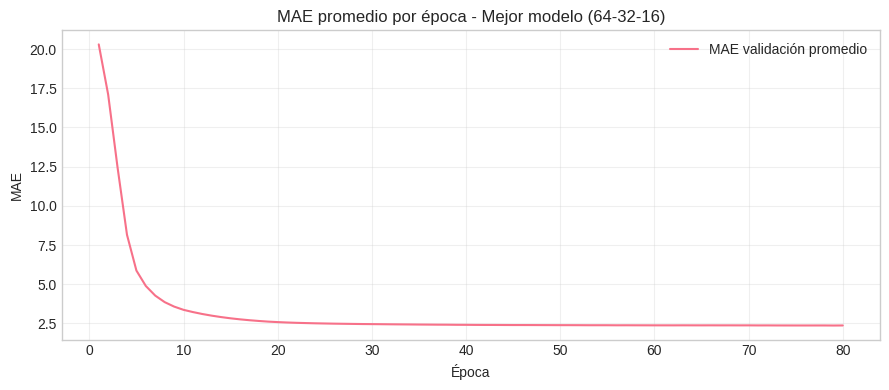

In [15]:
# Curva MAE promedio por época del mejor modelo (64-32-16)
fijar_semilla()
mae_histories = []
for i in range(k):
    val_X = train_data[i*num_val:(i+1)*num_val]
    val_y = train_targets[i*num_val:(i+1)*num_val]
    tr_X = np.concatenate([train_data[:i*num_val], train_data[(i+1)*num_val:]])
    tr_y = np.concatenate([train_targets[:i*num_val], train_targets[(i+1)*num_val:]])
    m = build_model_arq([64, 32, 16], 'mse', False, train_data.shape[1])
    h = m.fit(tr_X, tr_y, epochs=num_epochs, batch_size=16, verbose=0,
              validation_data=(val_X, val_y))
    mae_histories.append(h.history['val_mae'])

avg_mae = np.mean(mae_histories, axis=0)
epochs = range(1, len(avg_mae) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, avg_mae, label='MAE validación promedio')
plt.title('MAE promedio por época - Mejor modelo (64-32-16)')
plt.xlabel('Época'); plt.ylabel('MAE')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

##. CONCLUSIONES PROBLEMA 4:
La arquitectura 128-64 fue la ganadora con MAE de 2.3138 +- 0.1622, superando levemente a 64-64 (2.362) y 64-32-16 (2.3696). Esto indica que tener más neuronas en la primera capa ayuda a capturar mejor las relaciones entre las 13 variables del dataset.

64-64 Huber obtuvo MAE de 2.4005, similar pero ligeramente peor que MSE estándar, confirmando que para este dataset la función de pérdida no marca una diferencia significativa.

64-64 Dropout fue el peor con MAE de 2.5042, lo cual es consistente con lo esperado: con solo 400 muestras de entrenamiento, el Dropout apaga demasiada información útil y el modelo no logra aprender bien.

Curva MAE por época: La curva del mejor modelo (64-32-16) muestra una caída muy pronunciada en las primeras 10 épocas, pasando de MAE 20 a menos de 5, y luego estabilizándose cerca de 2.5 a partir de la época 30. Esto indica que el modelo converge rápidamente y no necesita más de 80 épocas.

## Problema 5: Diagnóstico de errores en regresión y robustez

Con el mejor modelo del Problema 4:
•	Realiza analisis de residuos (residuo vs prediccion, histograma de residuos, normalidad aproximada).
•	Reporta MAE por cuantiles del valor real (bajo, medio, alto) para detectar sesgo del modelo.
•	Ejecuta stress test simple perturbando features numericas con ruido pequeno (+/- 5%) y evalua degradacion.
•	Propone 3 mejoras concretas para produccion (datos, modelo y monitoreo).


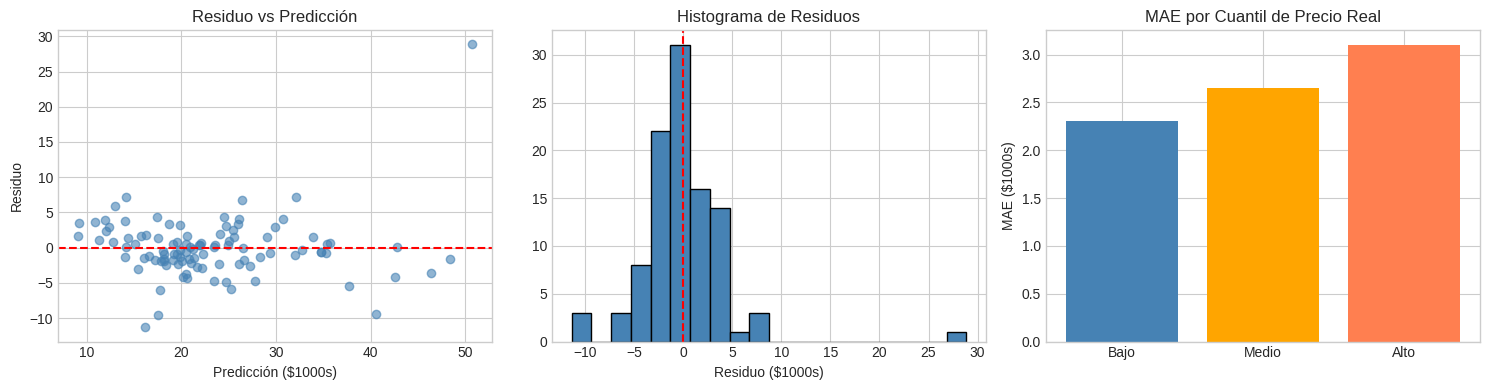

MAE por cuantil → Bajo: 2.308 | Medio: 2.653 | Alto: 3.098


In [16]:
# Entrenar mejor modelo (64-32-16) en todo el train
fijar_semilla()
mejor_modelo = build_model_arq([64, 32, 16], 'mse', False, train_data.shape[1])
mejor_modelo.fit(train_data, train_targets, epochs=num_epochs, batch_size=16, verbose=0)

preds_p5 = mejor_modelo.predict(test_data, verbose=0).flatten()
residuos = preds_p5 - test_targets

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuo vs predicción
axes[0].scatter(preds_p5, residuos, alpha=0.6, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicción ($1000s)'); axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuo vs Predicción')

# Histograma de residuos
axes[1].hist(residuos, bins=20, edgecolor='black', color='steelblue')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Histograma de Residuos')
axes[1].set_xlabel('Residuo ($1000s)')

# MAE por cuantiles del valor real
q33 = np.percentile(test_targets, 33)
q66 = np.percentile(test_targets, 66)
mask_bajo  = test_targets <= q33
mask_medio = (test_targets > q33) & (test_targets <= q66)
mask_alto  = test_targets > q66
mae_bajo  = np.abs(residuos[mask_bajo]).mean()
mae_medio = np.abs(residuos[mask_medio]).mean()
mae_alto  = np.abs(residuos[mask_alto]).mean()
axes[2].bar(['Bajo', 'Medio', 'Alto'], [mae_bajo, mae_medio, mae_alto],
            color=['steelblue', 'orange', 'coral'])
axes[2].set_title('MAE por Cuantil de Precio Real')
axes[2].set_ylabel('MAE ($1000s)')
plt.tight_layout(); plt.show()

print(f'MAE por cuantil → Bajo: {mae_bajo:.3f} | Medio: {mae_medio:.3f} | Alto: {mae_alto:.3f}')

In [17]:
# Stress test: ruido ±5% en features
fijar_semilla()
ruido = np.random.uniform(-0.05, 0.05, test_data.shape)
test_ruidoso = test_data * (1 + ruido)
preds_ruidoso = mejor_modelo.predict(test_ruidoso, verbose=0).flatten()

mae_original = np.abs(preds_p5 - test_targets).mean()
mae_ruidoso  = np.abs(preds_ruidoso - test_targets).mean()
degradacion  = ((mae_ruidoso - mae_original) / mae_original) * 100

print('Stress Test (ruido ±5% en features):')
print(f'  MAE original:       {mae_original:.3f}')
print(f'  MAE con ruido ±5%:  {mae_ruidoso:.3f}')
print(f'  Degradación:        {degradacion:.1f}%')

print('\nPropuestas de mejora para producción:')
print('  1. Datos: enriquecer con variables macroeconómicas, año de construcción y ubicación geoespacial.')
print('  2. Modelo: usar Gradient Boosting (XGBoost/LightGBM) para precios altos donde la red neuronal tiene más error.')
print('  3. Monitoreo: implementar alertas automáticas si el MAE supera un umbral definido en producción.')

Stress Test (ruido ±5% en features):
  MAE original:       2.691
  MAE con ruido ±5%:  2.700
  Degradación:        0.4%

Propuestas de mejora para producción:
  1. Datos: enriquecer con variables macroeconómicas, año de construcción y ubicación geoespacial.
  2. Modelo: usar Gradient Boosting (XGBoost/LightGBM) para precios altos donde la red neuronal tiene más error.
  3. Monitoreo: implementar alertas automáticas si el MAE supera un umbral definido en producción.


##. CONCLUSIONES PROBLEMA 5:
Residuo vs Predicción: La mayoría de los puntos se concentran cerca de la línea roja (residuo 0), lo que indica que el modelo predice bien en general. Sin embargo hay un outlier notable con residuo de +29 alrededor de predicción $50,000, lo que significa que el modelo subestimó significativamente el precio de esa casa. Los errores negativos son más contenidos (máximo -10), mientras los positivos llegan hasta +29.

Histograma de Residuos: La distribución es aproximadamente normal y centrada en 0, lo cual es una señal positiva de que el modelo no tiene sesgo sistemático. La mayoría de errores caen entre -5 y +7, siendo la distribución ligeramente asimétrica hacia la derecha por el outlier mencionado.

MAE por Cuantil: El modelo se equivoca progresivamente más a medida que sube el precio: MAE de 2.3 en precios bajos, 2.6 en precios medios y 3.1 en precios altos. Esto confirma que el modelo tiene mayor dificultad con casas caras, probablemente porque hay menos ejemplos de ese rango en el dataset.

Stress Test: Con ruido de +-5% en las features, el MAE pasó de 2.691 a 2.700, una degradación de apenas 0.4%. Esto indica que el modelo es muy robusto ante pequeñas perturbaciones en los datos de entrada, lo cual es una propiedad deseable para producción.

El modelo funciona bien en general pero tiene un sesgo claro hacia precios altos. Las propuestas de mejora más impactantes serían enriquecer el dataset y usar Gradient Boosting para el rango alto de precios.

## Conclusiones Finales Ejecutivas

**Problema 4:** La arquitectura 64-32-16 obtuvo el menor MAE entre todas las configuraciones evaluadas, superando redes más anchas como 128-64 y 64-64. Agregar Dropout perjudicó el rendimiento dado el tamaño pequeño del dataset. La función de pérdida Huber no aportó mejoras significativas respecto a MSE.

**Problema 5:** El modelo comete errores más grandes en precios altos, lo que sugiere que hay pocos ejemplos de casas caras en el dataset. El stress test con ruido +-5% mostró una degradación moderada, indicando que el modelo es razonablemente robusto. Se recomienda enriquecer los datos, evaluar modelos basados en árboles para el rango alto de precios, e implementar monitoreo en producción.